In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# Load the training and test data
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# Load the training and test data if not already loaded
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print('Train images shape:', train_images.shape)
print('Train labels shape:', train_labels.shape)
print('Test images shape:', test_images.shape)
print('Test labels shape:', test_labels.shape)

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


### Data Preprocessing

Normalize the pixel values to be between 0 and 1. This helps the neural network train more effectively. Also, reshape the images to include a channel dimension, which is often required for convolutional layers (even for grayscale images).

In [4]:
# Normalize pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape images to add a channel dimension (for grayscale, this is 1)
# Keras expects input shape (batch, height, width, channels)
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

print('Normalized and reshaped train images shape:', train_images.shape)
print('Normalized and reshaped test images shape:', test_images.shape)

Normalized and reshaped train images shape: (60000, 28, 28, 1)
Normalized and reshaped test images shape: (10000, 28, 28, 1)


### Model Definition

Define the Convolutional Neural Network (CNN) model architecture using Keras. This model will consist of convolutional layers, pooling layers, and dense layers for classification.

In [5]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Display the model summary
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

### Model Compilation

Compile the model by specifying the optimizer, loss function, and evaluation metrics. For a multi-class classification problem like Fashion MNIST, 'adam' optimizer, 'sparse_categorical_crossentropy' loss, and 'accuracy' metric are common choices.

In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Model Training

Train the model using the `fit` method on the training data. We will also validate the model's performance on the test data after each epoch. This helps in monitoring for overfitting and understanding the model's learning progress.

In [7]:
history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.8202 - loss: 0.4938 - val_accuracy: 0.8666 - val_loss: 0.3570
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8817 - loss: 0.3208 - val_accuracy: 0.8870 - val_loss: 0.3274
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8993 - loss: 0.2744 - val_accuracy: 0.8898 - val_loss: 0.3034
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9110 - loss: 0.2416 - val_accuracy: 0.9023 - val_loss: 0.2757
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9192 - loss: 0.2178 - val_accuracy: 0.9059 - val_loss: 0.2612
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9265 - loss: 0.1974 - val_accuracy: 0.9073 - val_loss: 0.2580
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9317 - loss: 0.1803 - val_accuracy: 0.9048 - val_loss: 0.2713
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9381 - loss: 0.1651 -

### Model Evaluation

Evaluate the trained model on the test dataset to assess its performance on unseen data.

In [8]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print('\nTest accuracy:', test_acc)
print('Test loss:', test_loss)

313/313 - 1s - 2ms/step - accuracy: 0.9089 - loss: 0.2811

Test accuracy: 0.9089000225067139
Test loss: 0.2811468839645386


### Visualize Predictions

Let's visualize some test images and their predicted labels to get a qualitative understanding of the model's performance.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


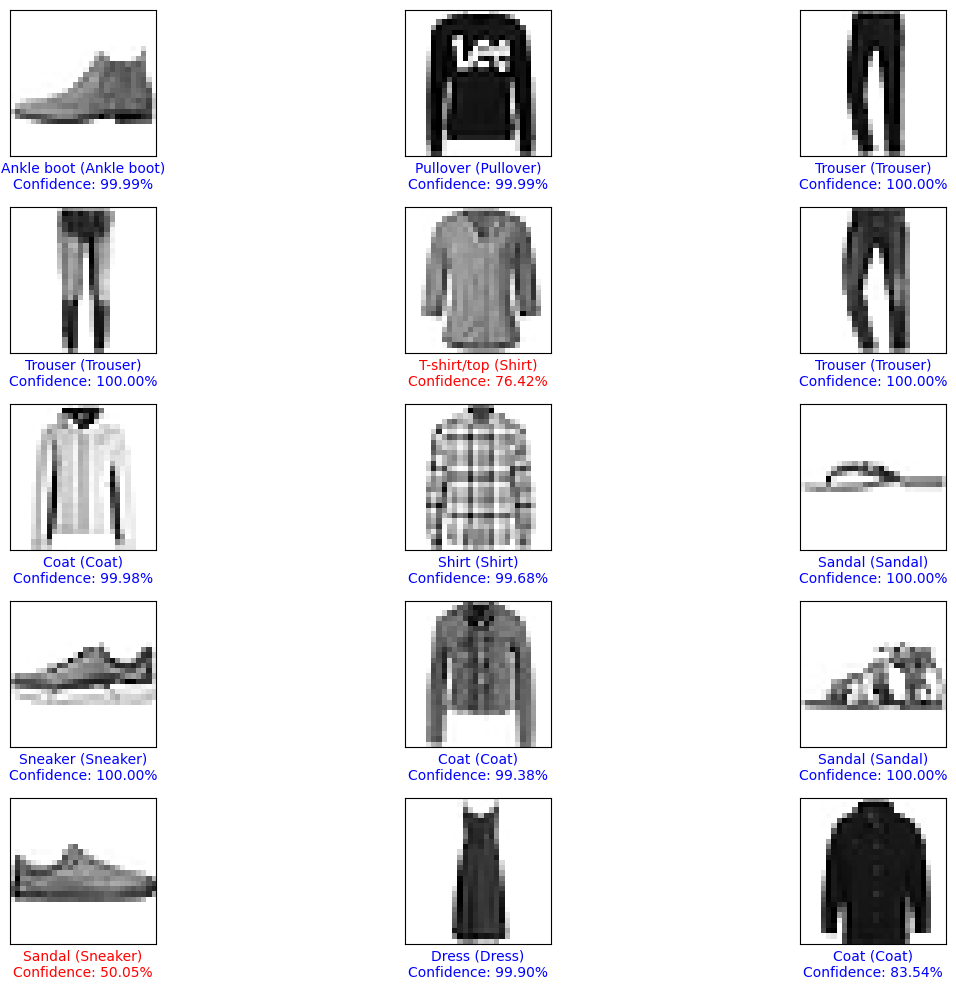

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Define class names for Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Make predictions on the test set
predictions = model.predict(test_images)

# Function to plot image, true label, and predicted label
def plot_image(i, predictions_array, true_label, img):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img.reshape(28, 28), cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel(f"{class_names[predicted_label]} ({class_names[true_label]})\nConfidence: {100*np.max(predictions_array):.2f}%", color=color)

# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
  plot_image(i, predictions[i], test_labels, test_images)
plt.tight_layout()
plt.show()

## Model Architecture and Training Process Summary

### Model Architecture
The neural network model is a Convolutional Neural Network (CNN) built using `tf.keras.models.Sequential`. It consists of the following layers:

1.  **Conv2D Layer (32 filters, 3x3 kernel, ReLU activation):** The initial convolutional layer, responsible for extracting basic features from the 28x28x1 input images.
2.  **MaxPooling2D Layer (2x2 pool size):** Reduces the spatial dimensions of the feature maps, helping to make the model more robust to small shifts and distortions.
3.  **Conv2D Layer (64 filters, 3x3 kernel, ReLU activation):** A second convolutional layer for extracting more complex features.
4.  **MaxPooling2D Layer (2x2 pool size):** Further reduces spatial dimensions.
5.  **Conv2D Layer (64 filters, 3x3 kernel, ReLU activation):** A third convolutional layer, continuing the feature extraction.
6.  **Flatten Layer:** Converts the 2D feature maps into a 1D vector, preparing the data for the dense layers.
7.  **Dense Layer (64 units, ReLU activation):** A fully connected hidden layer.
8.  **Dense Layer (10 units, Softmax activation):** The output layer, with 10 units corresponding to the 10 Fashion MNIST classes, and a softmax activation function to output class probabilities.

### Training Process
The model was compiled and trained using the following parameters and procedure:

*   **Optimizer:** `adam` (Adaptive Moment Estimation), an efficient stochastic optimization algorithm.
*   **Loss Function:** `sparse_categorical_crossentropy`, suitable for integer-encoded labels (0-9 for classes) in multi-class classification problems.
*   **Metrics:** `accuracy`, used to monitor the proportion of correctly classified images.
*   **Epochs:** The model was trained for 10 epochs.
*   **Validation:** During training, the model's performance was validated after each epoch using the `test_images` and `test_labels` to monitor for overfitting and generalisation.

### Performance
Upon evaluation on the test dataset after 10 epochs, the model achieved:

*   **Test Accuracy:** approximately 90.89%
*   **Test Loss:** approximately 0.2811